<a href="https://colab.research.google.com/github/fernandovidalnn/evaluacion_1_mineria_datos/blob/main/ev1_mineria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[LINK FUENTE DE DATOS](https://www.kaggle.com/datasets/anbudanadithya/spotify-music)

https://www.kaggle.com/datasets/anbudanadithya/spotify-music

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

In [2]:
df = pd.read_csv('Spotify_Music.csv')

In [3]:
# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)

# Para ver todas las filas (cuidado si el dataset es muy grande)
#pd.set_option('display.max_rows', None)

In [4]:
df.shape # visualizamos la cantidad de filas y columnas

(114000, 21)

In [5]:
df.head() #Visualizacion de las primeras 5 filas

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [6]:
df.tail() # visualización de las ultimas 5 filas

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,5,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,0,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,0,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,7,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,1,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


In [7]:
df.dtypes #vemos el tipo de dato de cada columna

,0
Unnamed: 0,int64
track_id,object
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64


In [8]:
df.isnull().sum() #contamos la cantidad de nulos por columna

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [9]:
 # Valores nulos
for feature in df.columns:
  print('Total de valores nulos de', feature, '=', df[feature].isna().sum())

Total de valores nulos de Unnamed: 0 = 0
Total de valores nulos de track_id = 0
Total de valores nulos de artists = 1
Total de valores nulos de album_name = 1
Total de valores nulos de track_name = 1
Total de valores nulos de popularity = 0
Total de valores nulos de duration_ms = 0
Total de valores nulos de explicit = 0
Total de valores nulos de danceability = 0
Total de valores nulos de energy = 0
Total de valores nulos de key = 0
Total de valores nulos de loudness = 0
Total de valores nulos de mode = 0
Total de valores nulos de speechiness = 0
Total de valores nulos de acousticness = 0
Total de valores nulos de instrumentalness = 0
Total de valores nulos de liveness = 0
Total de valores nulos de valence = 0
Total de valores nulos de tempo = 0
Total de valores nulos de time_signature = 0
Total de valores nulos de track_genre = 0


Podemos ver que contamos con un dataset casi completamente limpio y existe 1 nulo en 3 columanas distintas (artists, album_name y track_name) el resto de columnas no contienen nulos.

Realizaremos una aliminacion completa de los nulos.

In [10]:
df = df.dropna() #eliminacion de nulos completa y agresiva

confirmaremos la eliminación de los nulos.

In [11]:
 # Valores nulos
for feature in df.columns:
  print('Total de valores nulos de', feature, '=', df[feature].isna().sum())

Total de valores nulos de Unnamed: 0 = 0
Total de valores nulos de track_id = 0
Total de valores nulos de artists = 0
Total de valores nulos de album_name = 0
Total de valores nulos de track_name = 0
Total de valores nulos de popularity = 0
Total de valores nulos de duration_ms = 0
Total de valores nulos de explicit = 0
Total de valores nulos de danceability = 0
Total de valores nulos de energy = 0
Total de valores nulos de key = 0
Total de valores nulos de loudness = 0
Total de valores nulos de mode = 0
Total de valores nulos de speechiness = 0
Total de valores nulos de acousticness = 0
Total de valores nulos de instrumentalness = 0
Total de valores nulos de liveness = 0
Total de valores nulos de valence = 0
Total de valores nulos de tempo = 0
Total de valores nulos de time_signature = 0
Total de valores nulos de track_genre = 0


Revisaremos con cuantas filas quedó el df luego de la eliminación de los nulos

In [12]:
df.shape

(113999, 21)

Aplicamos dropna y eliminamos los nulos presentes que al finalizar vemos que era solo 1 fila que contenia 3 nulos en 3 columnas distintas

Revisaremos la cantidad de categorias únicas por cada columna

In [13]:
df.nunique()

,0
Unnamed: 0,113999
track_id,89740
artists,31437
album_name,46589
track_name,73608
popularity,101
duration_ms,50696
explicit,2
danceability,1174
energy,2083


In [14]:
df['explicit'].value_counts()

,count
explicit,
False,104252
True,9747


In [15]:
df['mode'].value_counts()

,count
mode,
1,72681
0,41318


In [16]:
df['key'].value_counts()

,count
key,
7,13244
0,13061
2,11644
9,11313
1,10772
5,9368
11,9282
4,9008
6,7921


In [17]:
df['time_signature'].value_counts()

,count
time_signature,
4,101842
3,9195
5,1826
1,973
0,163


In [18]:
df['track_genre'].value_counts().head(10)

,count
track_genre,
acoustic,1000
afrobeat,1000
alt-rock,1000
alternative,1000
ambient,1000
anime,1000
black-metal,1000
bluegrass,1000
blues,1000


El análisis de las variables categóricas con baja cardinalidad permite identificar patrones relevantes en el dataset. Se observa que algunas variables presentan distribuciones desbalanceadas, como explicit, mientras que otras, como track_genre, están balanceadas, lo que facilita su análisis comparativo. Además, variables como time_signature evidencian patrones claros propios de la estructura musical.

In [19]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

# **MAPEO DE DATOS**

## **Realizaremos un mapeo de datos de tu dataset de Spotify:**

Unnamed: 0: Numérico Discreto (Índice o conteo de filas)

track_id: Categórico Nominal (Identificador único de texto)

artists: Categórico Nominal

album_name: Categórico Nominal

track_name: Categórico Nominal

popularity: Numérico Discreto (Escala de 0 a 100)

duration_ms: Numérico Discreto (Tiempo expresado en milisegundos)

explicit: Categórico Nominal (Variable booleana/binaria)

danceability: Numérico Continuo

energy: Numérico Continuo

key: Categórico Ordinal (Representa notas musicales con un orden técnico,
aunque a veces se trata como nominal)

loudness: Numérico Continuo (Decibelios)

mode: Categórico Nominal (Binario: Mayor o Menor)

speechiness: Numérico Continuo

acousticness: Numérico Continuo

instrumentalness: Numérico Continuo

liveness: Numérico Continuo

valence: Numérico Continuo

tempo: Numérico Continuo (BPM)

time_signature: Numérico Discreto (Compás musical)

track_genre: Categórico Nominal


## **Clasificación de Variables:**

* Categórico Nominal:
Categorías sin un orden o jerarquía específica.
Ejemplo: track_id, artists, track_genre.
* Categórico Ordinal:
Categorías que siguen un orden lógico o escala.
Ejemplo: key (en contextos musicales) o niveles de popularidad si se agruparan por rangos (Baja, Media, Alta).
* Numérico Discreto:
Valores que surgen de un conteo y no admiten decimales en su unidad base.
Ejemplo: duration_ms, popularity, time_signature.
* Numérico Continuo:
Valores que resultan de una medición y pueden tener decimales.
Ejemplo: danceability, energy, loudness, tempo.

Generamos un resumen estadistico completo del df incluyendo todas las columnas numericas

In [20]:
df.describe(include='all')

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
count,113999.000000,113999,113999,113999,113999,113999.000000,1.139990e+05,113999,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999
unique,NaN,89740,31437,46589,73608,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,114
top,NaN,6S3JlDAGk3uu3NtZbPnuhS,The Beatles,Alternative Christmas 2022,Run Rudolph Run,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,acoustic
freq,NaN,9,279,195,151,NaN,NaN,104252,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000
mean,56999.421925,NaN,NaN,NaN,NaN,33.238827,2.280312e+05,NaN,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034,NaN
std,32909.243463,NaN,NaN,NaN,NaN,22.304959,1.072961e+05,NaN,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623,NaN
min,0.000000,NaN,NaN,NaN,NaN,0.000000,8.586000e+03,NaN,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,28499.500000,NaN,NaN,NaN,NaN,17.000000,1.740660e+05,NaN,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000,NaN
50%,56999.000000,NaN,NaN,NaN,NaN,35.000000,2.129060e+05,NaN,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000,NaN
75%,85499.500000,NaN,NaN,NaN,NaN,50.000000,2.615060e+05,NaN,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000,NaN


El siguiente código cuenta cuántas veces aparece cada valor en la columna

In [21]:
df['track_genre'].value_counts()

,count
track_genre,
acoustic,1000
afrobeat,1000
alt-rock,1000
alternative,1000
ambient,1000
...,...
techno,1000
turkish,1000
trip-hop,1000


El dataset presenta una distribución balanceada de géneros musicales, con 1000 registros por cada genero. la única excepcion es el género k-pop que presenta 999 debido a la eliminación de valores nulos.

Visualizaremos agrupando los datos por género (track_genre) y calcularemos el promedio de polularidad de cada uno, mostrando ordenadamente los géneros más populares primero.

In [22]:
df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

,popularity
track_genre,
pop-film,59.283000
k-pop,56.952953
chill,53.651000
sad,52.379000
grunge,49.594000
...,...
chicago-house,12.339000
detroit-techno,11.174000
latin,8.297000


Al analizar la popularidad promedio por género musical, se observa que existen diferencias significativas entre ellos. Géneros como pop-film y k-pop presentan los mayores niveles de popularidad promedio, mientras que géneros como iranian, romance y latin presentan los valores más bajos.

Esto indica claramente que no todos los géneros tienen el mismo nivel de aceptación o reproducción en la plataforma, evidenciando preferencias claras hacia ciertos estilos musicales.

Visualizaremos un histograma de todas las columnas númericas del df

array([[<Axes: title={'center': 'Unnamed: 0'}>,
        <Axes: title={'center': 'popularity'}>,
        <Axes: title={'center': 'duration_ms'}>,
        <Axes: title={'center': 'danceability'}>],
       [<Axes: title={'center': 'energy'}>,
        <Axes: title={'center': 'key'}>,
        <Axes: title={'center': 'loudness'}>,
        <Axes: title={'center': 'mode'}>],
       [<Axes: title={'center': 'speechiness'}>,
        <Axes: title={'center': 'acousticness'}>,
        <Axes: title={'center': 'instrumentalness'}>,
        <Axes: title={'center': 'liveness'}>],
       [<Axes: title={'center': 'valence'}>,
        <Axes: title={'center': 'tempo'}>,
        <Axes: title={'center': 'time_signature'}>, <Axes: >]],
      dtype=object)

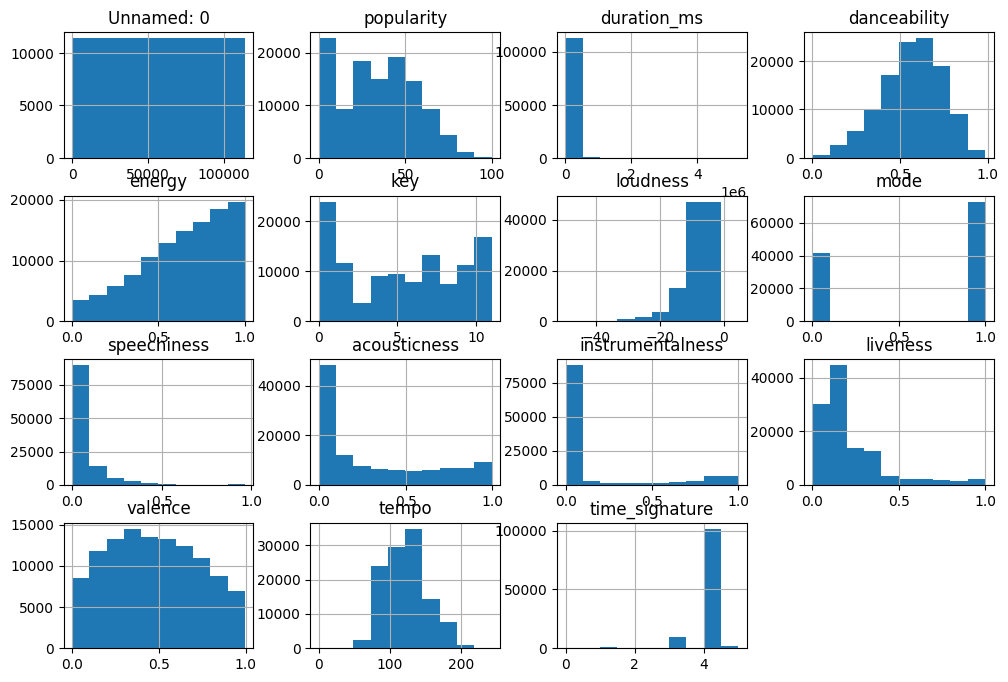

In [23]:
df.hist(figsize=(12,8))

In [24]:
cols_numericas = [
    'popularity', 'duration_ms', 'danceability', 'energy',
    'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo'
]

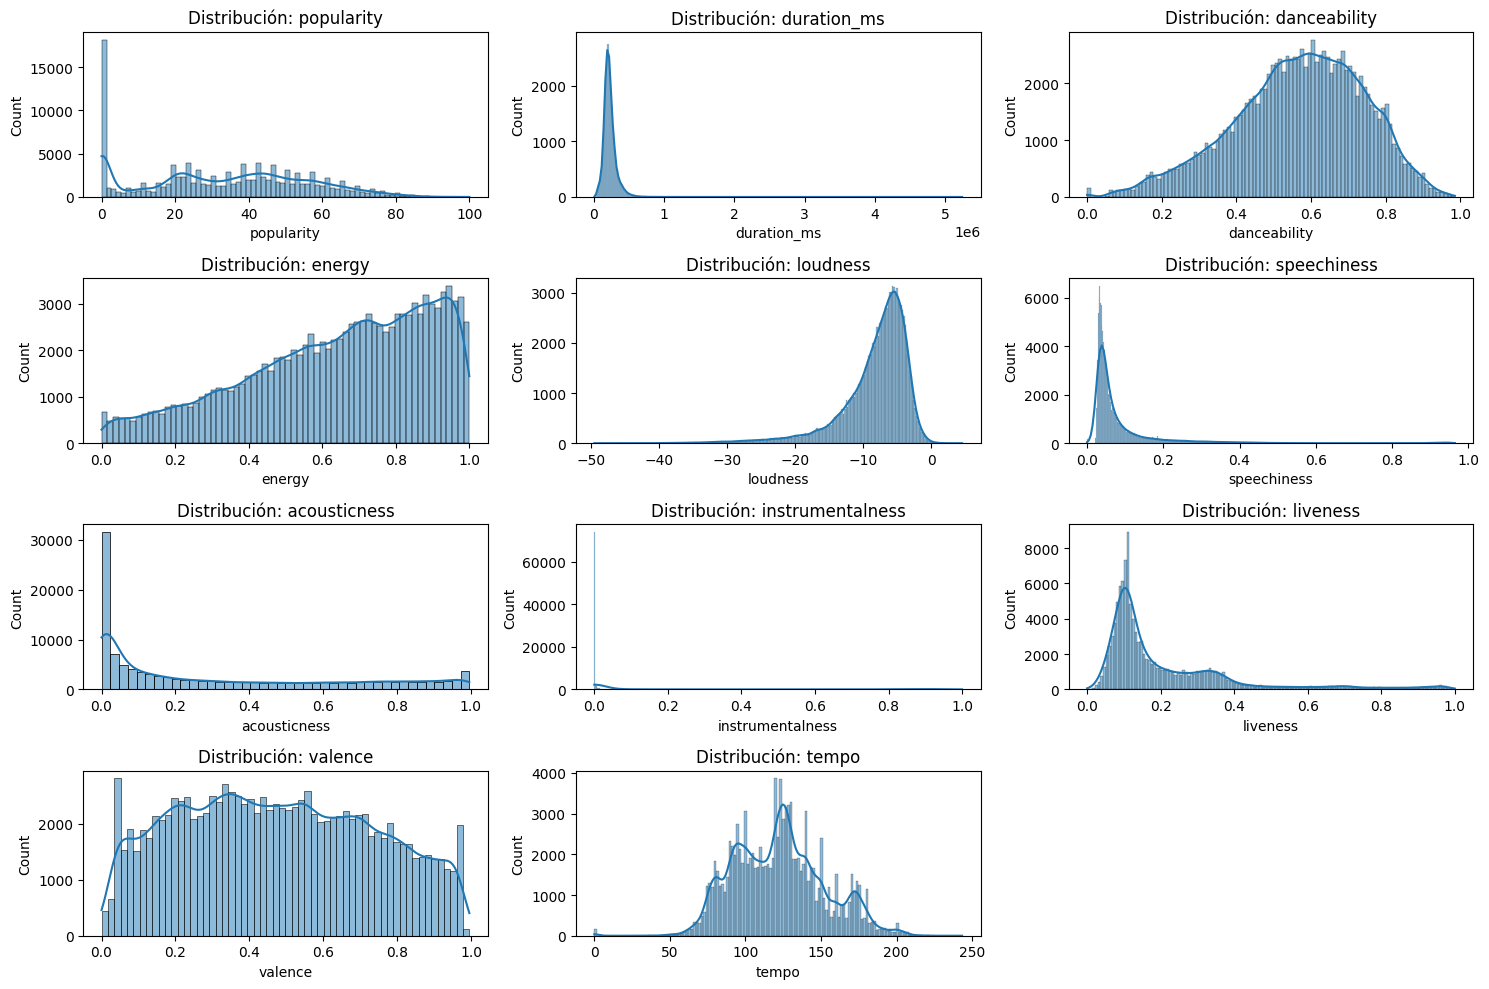

In [25]:
plt.figure(figsize=(15,10))

for i, col in enumerate(cols_numericas, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución: {col}')

plt.tight_layout()
plt.show()

El analisis de histogramas de las columnas nos permite observar la distribución de las variables númericas evidenciando que la mayoria de las canciones presentan valores bajos en caracteristicas como speechiness e instrumentalness, mientras que variables como energy y danceability muestran una mayor dispersión. Esto suguiere que predominan canciones energeticas y con ritmos moderados

Realizaremos un bloxplot con las variables númericas nos servira para detectar la distribución de los datos, mediana, rango y outliers

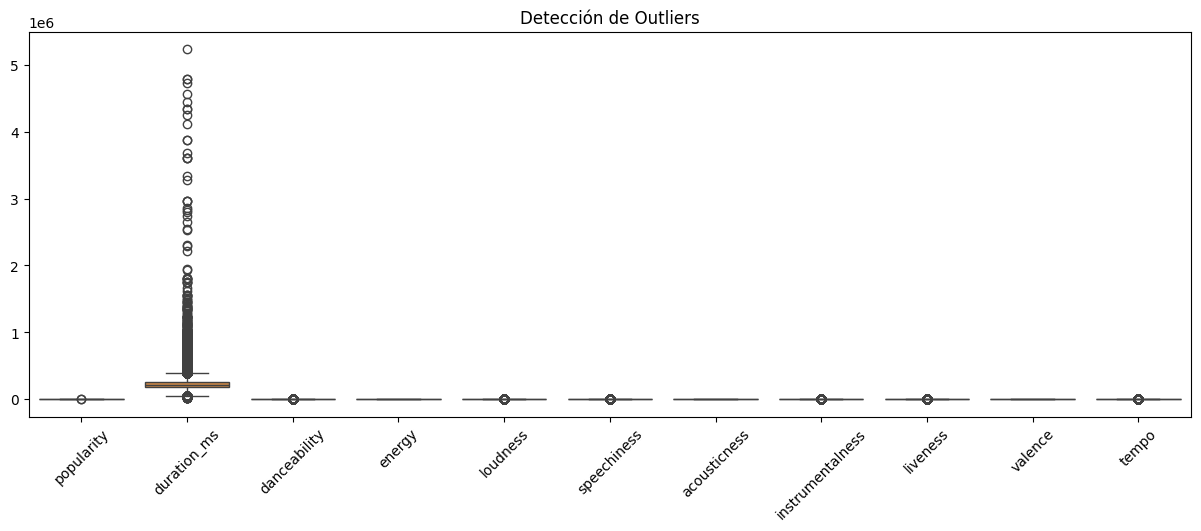

In [26]:
plt.figure(figsize=(15,5))
sns.boxplot(data=df[cols_numericas])
plt.xticks(rotation=45)
plt.title('Detección de Outliers')
plt.show()

Realizaremos los mismos boxplot pero excluyendo a duration_ms para poder visualizarlos mejor

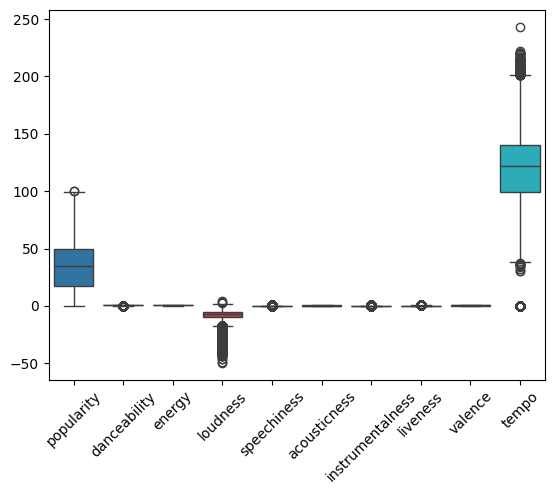

In [27]:
cols_sin_duration = [col for col in cols_numericas if col != 'duration_ms']

sns.boxplot(data=df[cols_sin_duration])
plt.xticks(rotation=45)
plt.show()

La variable duration_ms presenta muchos outliers y una escala mayor, lo que dificulta la visualización. Al excluirla, se observa que las demás variables tienen menor dispersión y pocos valores atípicos, aunque loudness y tempo aún muestran variabilidad. En general, los datos están concentrados y los outliers se concentran principalmente en la duración.

Se aplicará una estandarización a las variables numéricas mediante StandardScaler, con el fin de llevarlas a una escala común (media 0 y desviación estándar 1), permitiendo una mejor comparación y análisis de los datos.

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[cols_numericas] = scaler.fit_transform(df[cols_numericas])

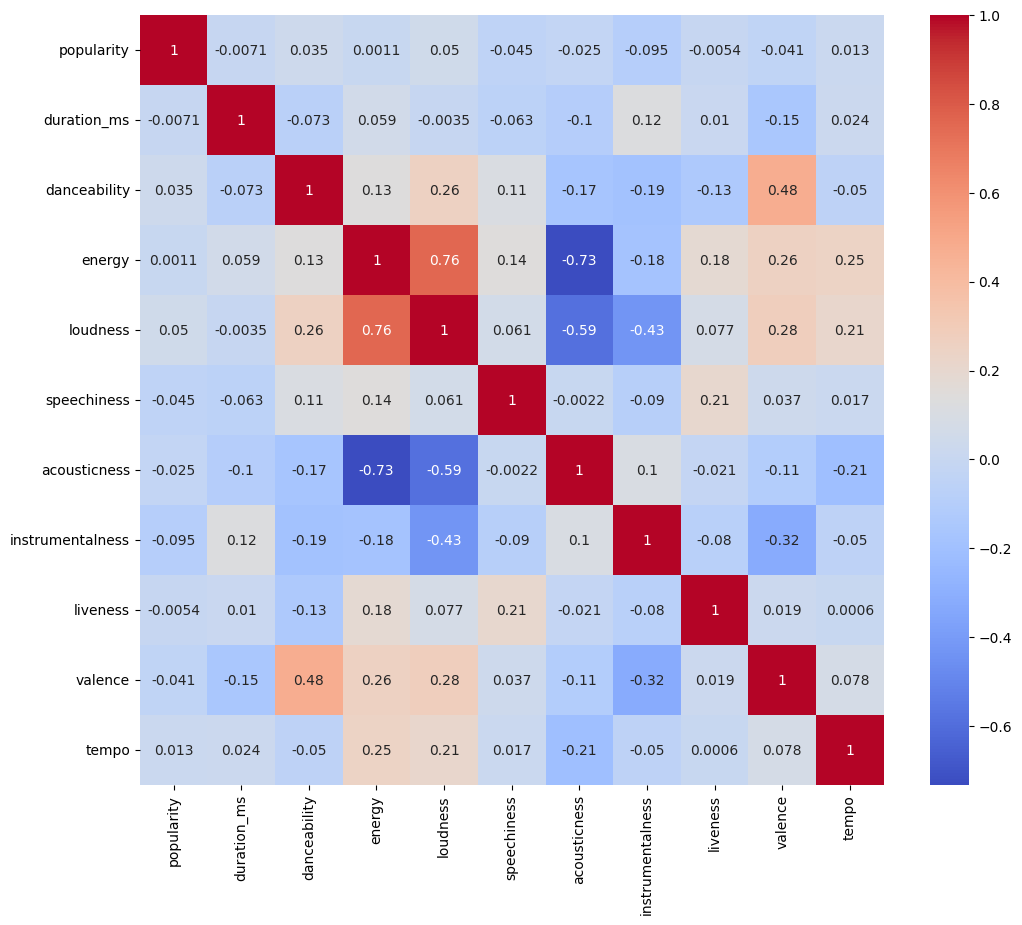

In [29]:
corr = df_scaled[cols_numericas].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

La matriz de correlación muestra que la variable popularity no presenta correlaciones fuertes con las demás variables, lo queindica que la popularidad de una canción no depende directamente de una sola característica musical

Las variables musicales presentan relaciones lógicas entre sí; sin embargo, ninguna de ellas explica por sí sola la popularidad, lo que sugiere que esta depende de múltiples factores externos como tendencias, artistas o contexto cultural

visualizaremos variables categoricas en graficos.

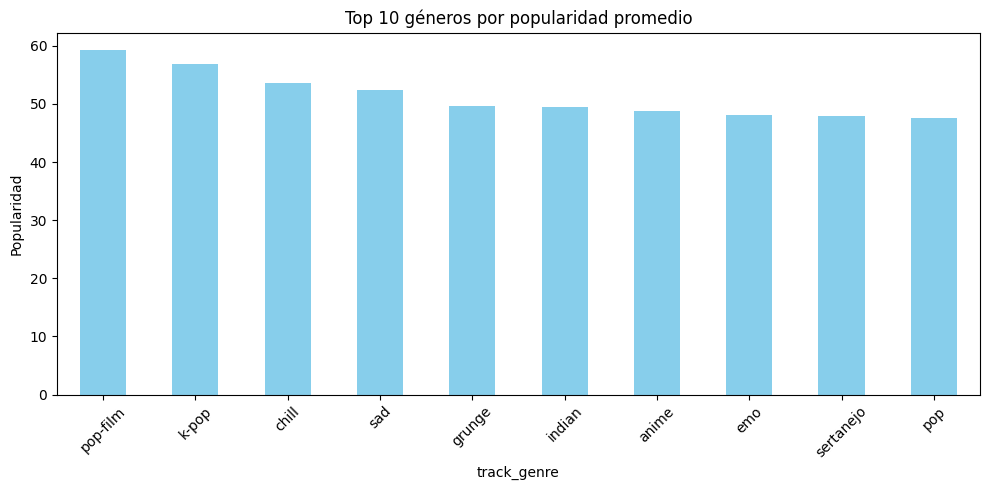

In [48]:
top_genres = df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_genres.plot(kind='bar', color='skyblue')
plt.title('Top 10 géneros por popularidad promedio')
plt.ylabel('Popularidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

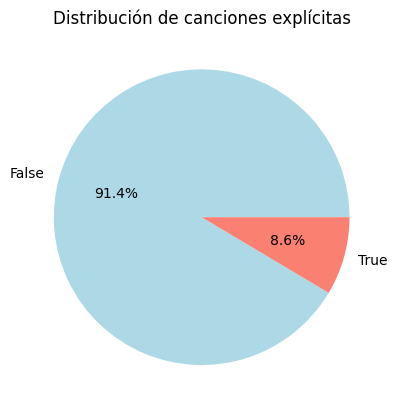

In [49]:
df['explicit'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['lightblue', 'salmon']
)

plt.title('Distribución de canciones explícitas')
plt.ylabel('')
plt.show()

Realizaremos encoder en explicit y track_genre

Crearemos df_model que sera una copia de df original

In [32]:
df_model = df.copy()

In [33]:
df_model['explicit'] = df_model['explicit'].astype(int)

In [35]:
df_model = pd.get_dummies(df_model, columns=['track_genre'], drop_first=True)

In [37]:
df_model.shape

(113999, 133)

In [38]:
df_model.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,track_genre_black-metal,track_genre_bluegrass,track_genre_blues,track_genre_brazil,track_genre_breakbeat,track_genre_british,track_genre_cantopop,track_genre_chicago-house,track_genre_children,track_genre_chill,track_genre_classical,track_genre_club,track_genre_comedy,track_genre_country,track_genre_dance,track_genre_dancehall,track_genre_death-metal,track_genre_deep-house,track_genre_detroit-techno,track_genre_disco,track_genre_disney,track_genre_drum-and-bass,track_genre_dub,track_genre_dubstep,track_genre_edm,track_genre_electro,track_genre_electronic,track_genre_emo,track_genre_folk,track_genre_forro,track_genre_french,track_genre_funk,track_genre_garage,track_genre_german,track_genre_gospel,track_genre_goth,track_genre_grindcore,track_genre_groove,track_genre_grunge,track_genre_guitar,track_genre_happy,track_genre_hard-rock,track_genre_hardcore,track_genre_hardstyle,track_genre_heavy-metal,track_genre_hip-hop,track_genre_honky-tonk,track_genre_house,track_genre_idm,track_genre_indian,track_genre_indie,track_genre_indie-pop,track_genre_industrial,track_genre_iranian,track_genre_j-dance,track_genre_j-idol,track_genre_j-pop,track_genre_j-rock,track_genre_jazz,track_genre_k-pop,track_genre_kids,track_genre_latin,track_genre_latino,track_genre_malay,track_genre_mandopop,track_genre_metal,track_genre_metalcore,track_genre_minimal-techno,track_genre_mpb,track_genre_new-age,track_genre_opera,track_genre_pagode,track_genre_party,track_genre_piano,track_genre_pop,track_genre_pop-film,track_genre_power-pop,track_genre_progressive-house,track_genre_psych-rock,track_genre_punk,track_genre_punk-rock,track_genre_r-n-b,track_genre_reggae,track_genre_reggaeton,track_genre_rock,track_genre_rock-n-roll,track_genre_rockabilly,track_genre_romance,track_genre_sad,track_genre_salsa,track_genre_samba,track_genre_sertanejo,track_genre_show-tunes,track_genre_singer-songwriter,track_genre_ska,track_genre_sleep,track_genre_songwriter,track_genre_soul,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,

Se transformaron las variables categóricas a formato numérico mediante encoding, generando nuevas columnas binarias y aumentando la dimensionalidad del dataset.

In [39]:
df_model = df_model.drop(columns=[
    'Unnamed: 0',
    'track_id',
    'artists',
    'album_name',
    'track_name'
])

Se eliminaron variables como track_id, artists, album_name y track_name, ya que corresponden a identificadores o variables categóricas de alta cardinalidad que no aportan valor al análisis numérico ni a la matriz de correlación.

In [40]:
df_model.head()

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,track_genre_black-metal,track_genre_bluegrass,track_genre_blues,track_genre_brazil,track_genre_breakbeat,track_genre_british,track_genre_cantopop,track_genre_chicago-house,track_genre_children,track_genre_chill,track_genre_classical,track_genre_club,track_genre_comedy,track_genre_country,track_genre_dance,track_genre_dancehall,track_genre_death-metal,track_genre_deep-house,track_genre_detroit-techno,track_genre_disco,track_genre_disney,track_genre_drum-and-bass,track_genre_dub,track_genre_dubstep,track_genre_edm,track_genre_electro,track_genre_electronic,track_genre_emo,track_genre_folk,track_genre_forro,track_genre_french,track_genre_funk,track_genre_garage,track_genre_german,track_genre_gospel,track_genre_goth,track_genre_grindcore,track_genre_groove,track_genre_grunge,track_genre_guitar,track_genre_happy,track_genre_hard-rock,track_genre_hardcore,track_genre_hardstyle,track_genre_heavy-metal,track_genre_hip-hop,track_genre_honky-tonk,track_genre_house,track_genre_idm,track_genre_indian,track_genre_indie,track_genre_indie-pop,track_genre_industrial,track_genre_iranian,track_genre_j-dance,track_genre_j-idol,track_genre_j-pop,track_genre_j-rock,track_genre_jazz,track_genre_k-pop,track_genre_kids,track_genre_latin,track_genre_latino,track_genre_malay,track_genre_mandopop,track_genre_metal,track_genre_metalcore,track_genre_minimal-techno,track_genre_mpb,track_genre_new-age,track_genre_opera,track_genre_pagode,track_genre_party,track_genre_piano,track_genre_pop,track_genre_pop-film,track_genre_power-pop,track_genre_progressive-house,track_genre_psych-rock,track_genre_punk,track_genre_punk-rock,track_genre_r-n-b,track_genre_reggae,track_genre_reggaeton,track_genre_rock,track_genre_rock-n-roll,track_genre_rockabilly,track_genre_romance,track_genre_sad,track_genre_salsa,track_genre_samba,track_genre_sertanejo,track_genre_show-tunes,track_genre_singer-songwriter,track_genre_ska,track_genre_sleep,track_genre_songwriter,track_genre_soul,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.00000

In [41]:
cols_model = df_model.select_dtypes(include=['int64','float64']).columns

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_model_scaled = df_model.copy()
df_model_scaled[cols_model] = scaler.fit_transform(df_model[cols_model])

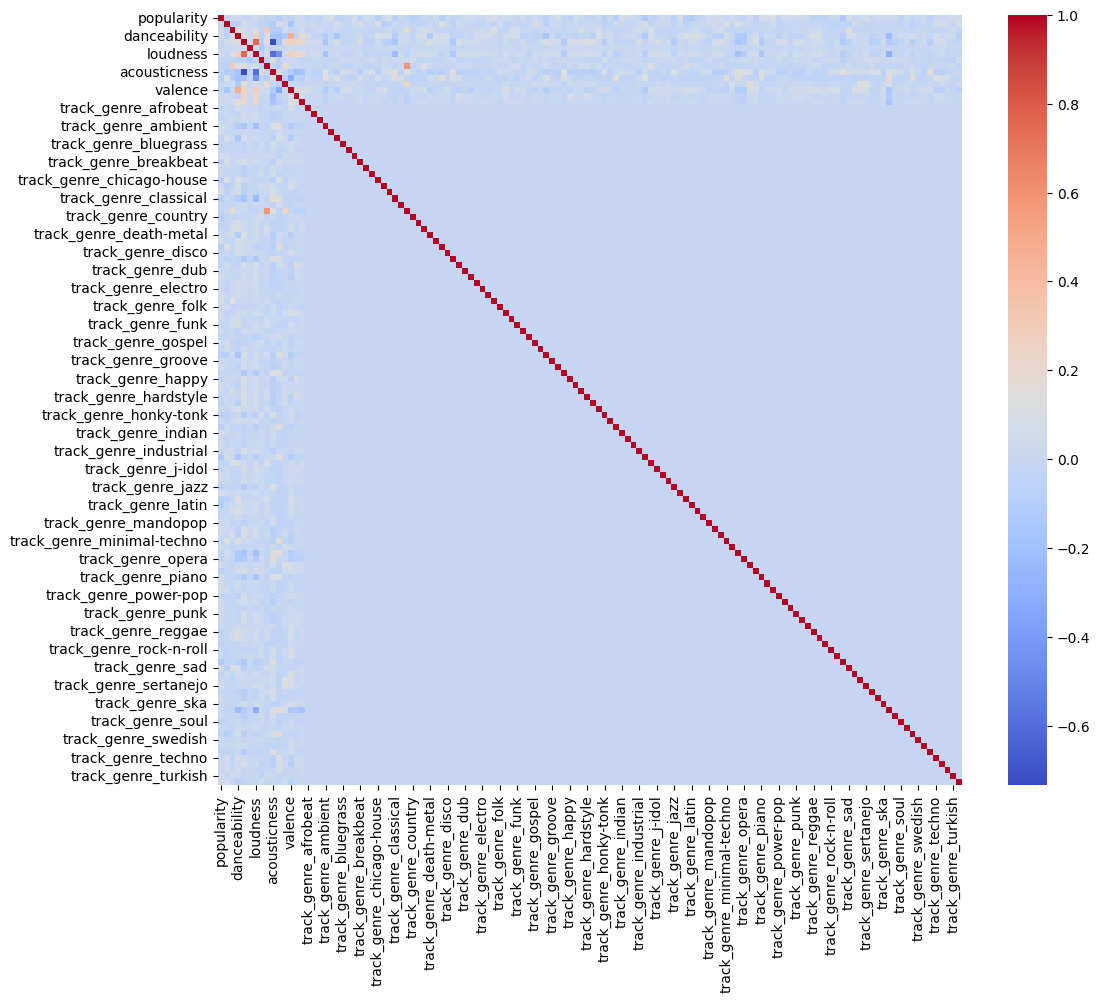

In [45]:
corr_model = df_model_scaled.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_model, cmap='coolwarm')
plt.show()

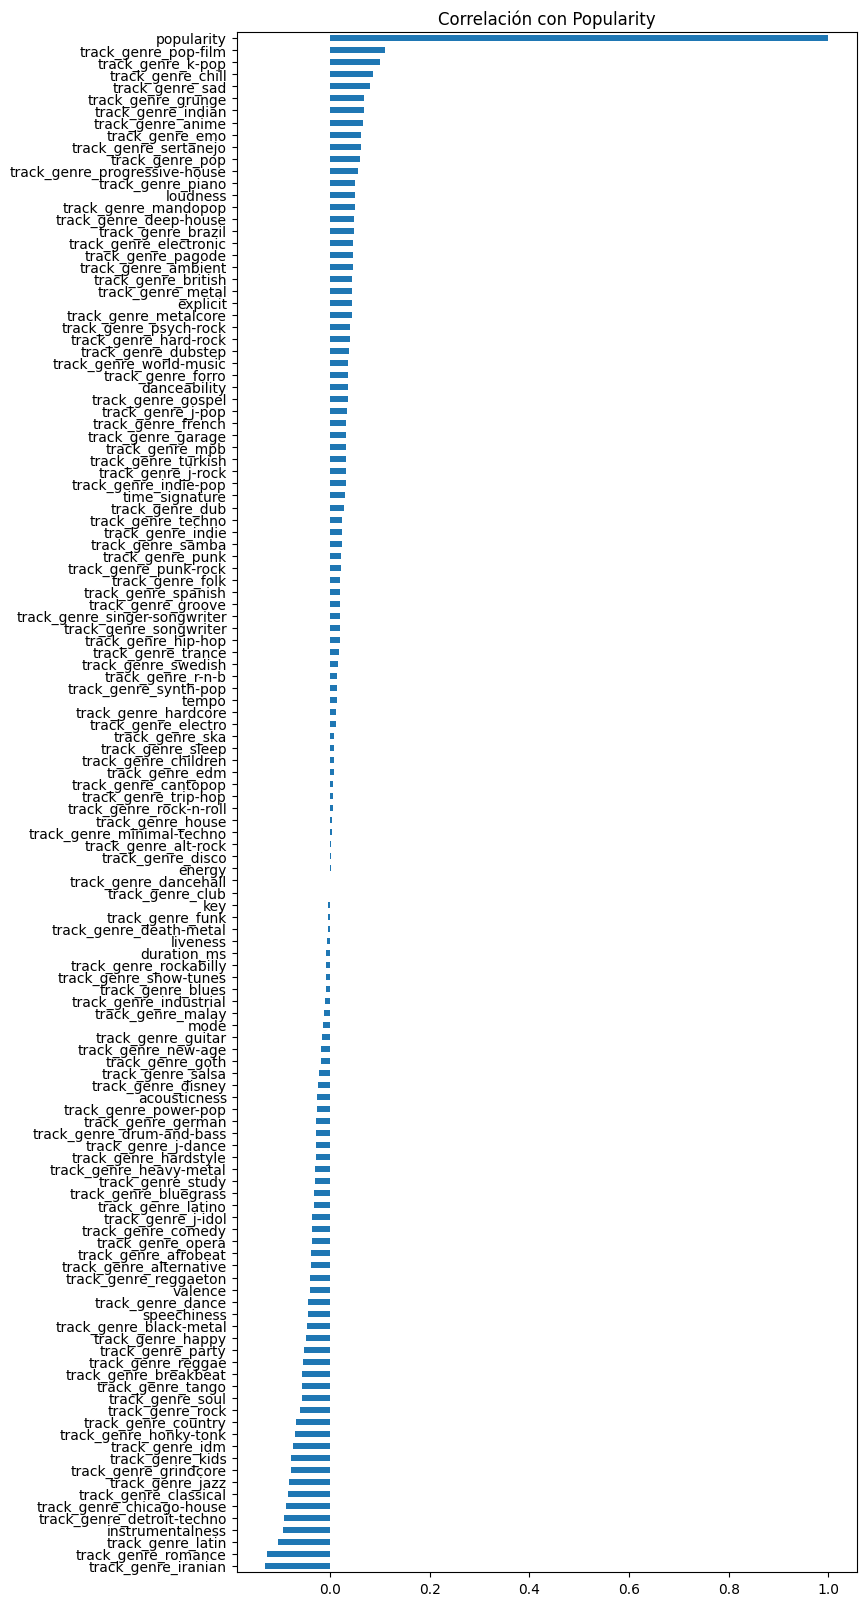

In [46]:
corr_pop = df_model_scaled.corr()['popularity'].sort_values()

plt.figure(figsize=(8,20))
corr_pop.plot(kind='barh')
plt.title('Correlación con Popularity')
plt.show()

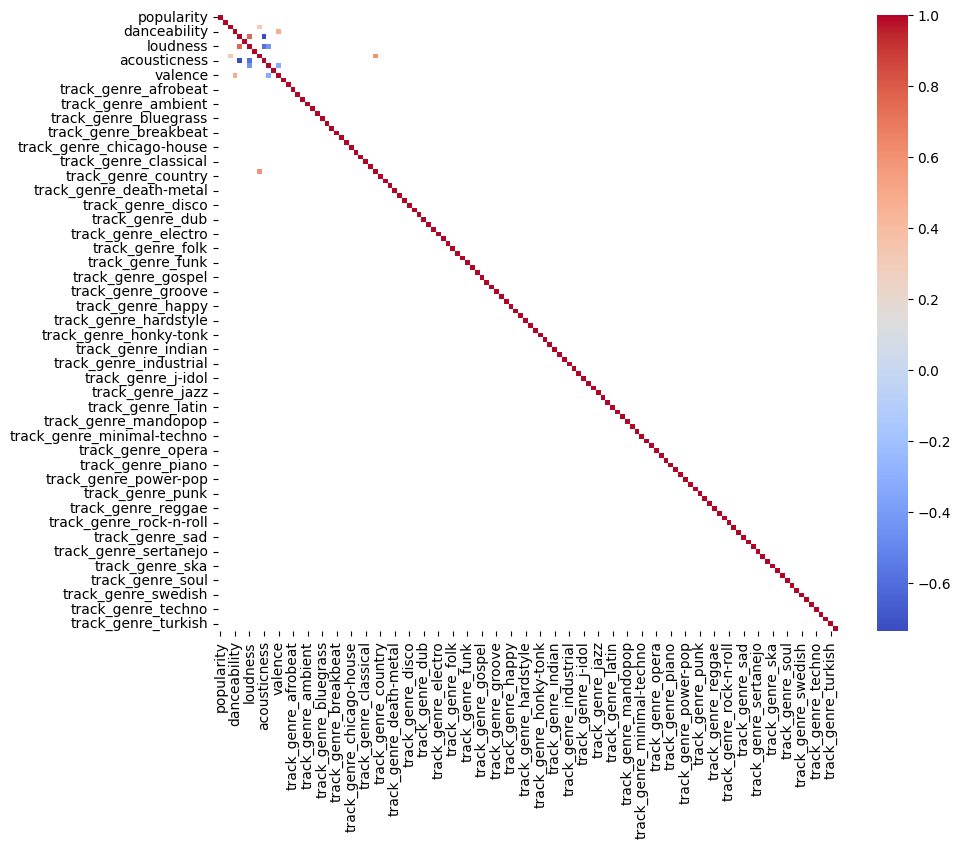

In [47]:
corr = df_model_scaled.corr()

corr_filtrada = corr[abs(corr) > 0.3]

plt.figure(figsize=(10,8))
sns.heatmap(corr_filtrada, cmap='coolwarm')
plt.show()

Debido a la alta dimensionalidad generada por el encoding de la variable track_genre, se optó por filtrar las variables más relevantes para facilitar la interpretación de la matriz de correlación.

Tras aplicar encoding, se observa que la mayoría de las variables presentan correlaciones débiles con la popularidad, lo que indica que esta no depende de una sola característica. Algunos géneros muestran una leve relación positiva o negativa, pero en general la influencia es baja. Además, variables como danceability y loudness presentan relaciones entre sí, reflejando patrones musicales esperados.